# Investigate Salary Distribution in Data Roles in the United Kingdom

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [3]:
# Data Cleaning:

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [6]:
country = 'United Kingdom'

In [7]:
df_UK = df[df['job_country'] == country].copy().dropna(subset=['salary_year_avg'])

In [8]:
job_titles = df_UK['job_title_short'].value_counts().index[:6].tolist()

job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [9]:
df_UK_top_6 = df_UK[df_UK['job_title_short'].isin(job_titles)]

In [18]:
job_titles_order = df_UK_top_6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

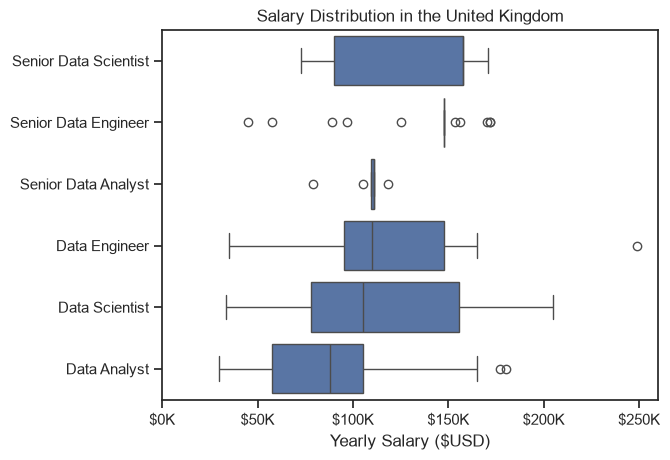

In [19]:
sns.set_theme(style="ticks")

sns.boxplot(data=df_UK_top_6, x='salary_year_avg', y='job_title_short', order=job_titles_order)

plt.title(f"Salary Distribution in the {country}")
plt.xlabel("Yearly Salary ($USD)")
plt.ylabel(None)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x / 1000)}K"))
plt.xlim(0, 260000)
plt.show()

# Investigate Median Salary vs. Skills for Data Analysts in the United Kingdom

In [20]:
role = 'Data Analyst'

In [23]:
df_DA_UK = df[(df['job_title_short'] == role) & (df['job_country'] == country)].copy()

df_DA_UK = df_DA_UK.dropna(subset=['salary_year_avg'])

df_DA_UK

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,"[excel, word, outlook]","{'analyst_tools': ['excel', 'word', 'outlook']}"
16526,Data Analyst,Portfolio Data Feeds - Associate Portfolio Dat...,"Edinburgh, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-05-24 13:11:25,False,False,United Kingdom,year,100500.0,NaN,Addepar,"[sql, jupyter]","{'libraries': ['jupyter'], 'programming': ['sq..."
25994,Data Analyst,Data Analyst,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-04 13:16:42,False,False,United Kingdom,year,105000.0,NaN,Informa Group Plc.,"[go, gdpr, dax]","{'analyst_tools': ['dax'], 'libraries': ['gdpr..."
30265,Data Analyst,Data & Insight Analyst,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-03-24 13:22:35,True,False,United Kingdom,year,80850.0,NaN,Mention Me,"[go, bigquery, looker]","{'analyst_tools': ['looker'], 'cloud': ['bigqu..."
84680,Data Analyst,Data Analyst,"Stockport, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-23 00:12:17,True,False,United Kingdom,year,105000.0,NaN,NielsenIQ,[sql],{'programming': ['sql']}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
748172,Data Analyst,Healthcare Data Analyst,"Hemel Hempstead, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-03-01 20:26:22,False,False,United Kingdom,year,53014.0,NaN,NECSWS,"[sql, sql server]","{'databases': ['sql server'], 'programming': [..."
758707,Data Analyst,Data Analyst- Gas & Power,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-14 20:16:23,False,False,United Kingdom,year,100500.0,NaN,Energy Aspects Ltd,"[python, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
760011,Data Analyst,"Research Engineer, Science","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-28 21:00:41,False,False,United Kingdom,year,177283.0,NaN,DeepMind,"[python, c++, tensorflow, pytorch, numpy, pandas]","{'libraries': ['tensorflow', 'pytorch', 'numpy..."
762692,Data Analyst,Data Analyst - Manager Research,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-09 04:18:12,False,False,United Kingdom,year,51014.0,NaN,Redington,[excel],{'analyst_tools': ['excel']}


In [26]:
df_DA_UK = df_DA_UK.explode('job_skills')

df_DA_UK[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
2602,51014.0,excel
2602,51014.0,word
2602,51014.0,outlook
16526,100500.0,sql
16526,100500.0,jupyter


In [29]:
df_DA_UK_top_pay = df_DA_UK.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_DA_UK_top_pay = df_DA_UK_top_pay.head(10)

df_DA_UK_top_pay

,count,median
job_skills,,
c++,1,177283.0
numpy,1,177283.0
tensorflow,1,177283.0
pytorch,1,177283.0
pandas,1,177283.0
aurora,1,165000.0
kafka,1,165000.0
aws,3,165000.0
mysql,3,165000.0


In [31]:
df_DA_UK_skills = df_DA_UK.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_UK_skills = df_DA_UK_skills.head(10).sort_values(by='median', ascending=False)

df_DA_UK_skills

,count,median
job_skills,,
tableau,13,100500.0
sql,33,98500.0
looker,6,96012.5
power bi,7,89100.0
python,25,89100.0
sas,8,80007.0
r,9,77017.5
excel,29,75550.0
go,9,71000.0


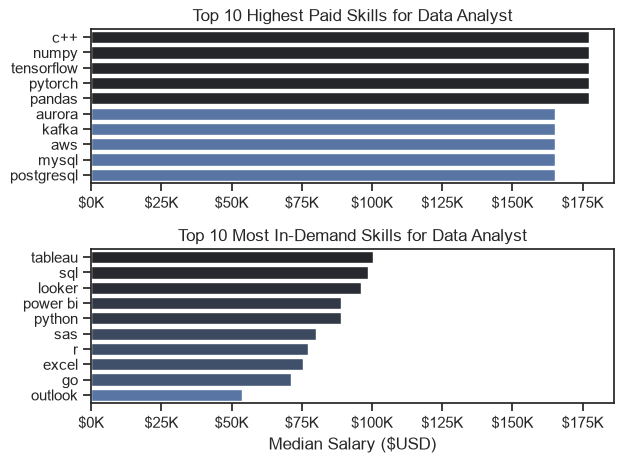

In [35]:
fig, ax = plt.subplots(2, 1)

sns.set_theme(style="ticks")

# df_DA_UK_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
barplot_1 = sns.barplot(data=df_DA_UK_top_pay, x=df_DA_UK_top_pay['median'], y=df_DA_UK_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r')
barplot_1.invert_yaxis()
ax[0].invert_yaxis() # Also need this line to invert for some reason
ax[0].legend().remove()
ax[0].set_title("Top 10 Highest Paid Skills for Data Analyst")
ax[0].set_xlabel(None)
ax[0].set_ylabel(None)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x / 1000)}K"))


# df_DA_UK_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
barplot_2 = sns.barplot(data=df_DA_UK_skills, x=df_DA_UK_skills['median'], y=df_DA_UK_skills.index, ax=ax[1], hue='median', palette='dark:b_r')
barplot_2.invert_yaxis()
ax[1].invert_yaxis() # Also need this line to invert for some reason
ax[1].legend().remove()
ax[1].set_title("Top 10 Most In-Demand Skills for Data Analyst")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_xlabel("Median Salary ($USD)")
ax[1].set_ylabel(None)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x / 1000)}K"))

fig.tight_layout()
plt.show()